In [1]:
# compute topic modelling metrics

# for each doc: tanh (num of topic switches / num of sentence transitions)
# averaged across docs

In [2]:
import os
from tqdm import tqdm
from pathlib import Path
import pandas as pd
import json
import numpy as np

In [3]:
BERTOPIC_DATA_DIR = Path('/mimer/NOBACKUP/groups/naiss2025-22-1187/data/bertopic_inputs')
BERTOPIC_CACHE_DIR = Path('/mimer/NOBACKUP/groups/naiss2024-6-297/cache/bertopic_bootstrapped/full_training_10')
NR_TOPICS_LIST = list(range(5, 85, 5))  # [5, 10, 15, ..., 80]
ROBERTA_EXCLUDED_STORY_IDS = [1214, 3761, 5047, 5540, 7195, 10499]

# trained on balanced bootstrapped sets (720 stories each, 10 bootstraps)
# min_topic_size=10 (HDBSCAN default), nr_topics reduced from 80 down to 5 in steps of 5

In [4]:
def load_bertopic_metadata():
    metadata = pd.read_csv(BERTOPIC_DATA_DIR / 'all_stories_metadata.csv')
    with open(BERTOPIC_DATA_DIR / 'all_stories_texts.json', 'r') as f:
        stories = json.load(f)
    return metadata, stories

def create_sentence_to_story_mapping(stories, metadata):
    rows = []
    current_idx = 0
    for doc_id, doc in enumerate(stories):
        sentences = [sent.strip() for sent in doc.split('[SENT]') if sent.strip()]
        story_meta = metadata[metadata['story_index'] == doc_id].iloc[0]
        for pos, sent in enumerate(sentences):
            rows.append({
                'sentence_idx': current_idx, 'sentence_pos': pos,
                'n_sentences': len(sentences), 'story_index': doc_id,
                'story_id': story_meta['doc_key'],
                'model_type': story_meta['model_type'],
                'prompt_type': story_meta['prompt_type'],
                'seed': story_meta['seed'],
            })
            current_idx += 1
    return pd.DataFrame(rows)

def load_sentence_topics_for_config(bootstrap_idx, nr_topics):
    topic_path = BERTOPIC_CACHE_DIR / 'inference' / f'bootstrap_{bootstrap_idx:02d}' / f'topics_{nr_topics}' / 'sentence_topics.npy'
    if topic_path.exists():
        return np.load(topic_path)
    return None

In [5]:
def compute_topic_switch_rate(group):
    group = group.sort_values('sentence_pos')
    topics = group['topic'].values
    if len(topics) < 2:
        return np.nan
    n_changes = sum(1 for i in range(len(topics) - 1) if topics[i] != topics[i + 1])
    return np.tanh(n_changes / (len(topics) - 1))

In [6]:
def filter_by_seed_rules(df):
    original = df[(df['prompt_type'] == 'original') & (df['seed'] == 42)]
    large_ai = df[(df['prompt_type'] == 'large') & (df['model_type'] != 'human') & (df['seed'] == 42)]
    large_human = df[(df['prompt_type'] == 'large') & (df['model_type'] == 'human')]
    return pd.concat([original, large_ai, large_human], ignore_index=True)

def load_topic_switch_data(excluded_story_ids=None):
    metadata, stories = load_bertopic_metadata()
    sentence_mapping = create_sentence_to_story_mapping(stories, metadata)

    inference_dir = BERTOPIC_CACHE_DIR / 'inference'

    available_configs = []
    for bootstrap_dir in sorted(os.listdir(inference_dir)):
        bootstrap_path = inference_dir / bootstrap_dir
        if not os.path.isdir(bootstrap_path):
            continue
        bootstrap_idx = int(bootstrap_dir.split('_')[1])
        for nr_topics in NR_TOPICS_LIST:
            topic_path = bootstrap_path / f'topics_{nr_topics}' / 'sentence_topics.npy'
            if topic_path.exists():
                available_configs.append((bootstrap_idx, nr_topics))

    all_topics_data = []
    for bootstrap_idx, nr_topics in tqdm(available_configs, desc="Loading topic configs"):
        topics = load_sentence_topics_for_config(bootstrap_idx, nr_topics)
        if topics is not None:
            df = sentence_mapping.copy()
            df['topic'] = topics
            df['bootstrap_idx'] = bootstrap_idx
            df['nr_topics'] = nr_topics
            all_topics_data.append(df)

    sentence_topics_df = pd.concat(all_topics_data, ignore_index=True)

    filtered_df = filter_by_seed_rules(sentence_topics_df)

    all_change_rates = filtered_df.groupby(
        ['model_type', 'prompt_type', 'seed', 'story_index', 'story_id', 'bootstrap_idx', 'nr_topics']
    ).apply(compute_topic_switch_rate).reset_index(name='topic_switch_rate')

    is_hl = (all_change_rates['model_type'] == 'human') & (all_change_rates['prompt_type'] == 'large')
    non_hl = all_change_rates[~is_hl][['model_type', 'prompt_type', 'story_id', 'bootstrap_idx', 'nr_topics', 'topic_switch_rate']]

    hl = all_change_rates[is_hl].groupby(['model_type', 'prompt_type', 'story_id', 'bootstrap_idx', 'nr_topics']).agg(
        topic_switch_rate=('topic_switch_rate', 'mean')
    ).reset_index()

    combined = pd.concat([non_hl, hl], ignore_index=True)

    story_avg = combined.groupby(['model_type', 'prompt_type', 'story_id']).agg(
        topic_switch_rate=('topic_switch_rate', 'mean')
    ).reset_index()

    story_lengths = filter_by_seed_rules(sentence_mapping).groupby(['model_type', 'prompt_type', 'story_id']).agg(
        n_sentences=('n_sentences', 'mean')
    ).reset_index()

    story_avg = story_avg.merge(
        story_lengths,
        on=['model_type', 'prompt_type', 'story_id'],
        how='left'
    )

    story_avg = story_avg.rename(columns={'model_type': 'model', 'prompt_type': 'prompt'})

    if excluded_story_ids:
        excluded_story_ids = {int(x) for x in excluded_story_ids}
        story_avg['story_id_numeric'] = pd.to_numeric(story_avg['story_id'], errors='coerce')
        story_avg = story_avg[story_avg['story_id_numeric'].notna()].copy()
        story_avg['story_id_numeric'] = story_avg['story_id_numeric'].astype(int)
        story_avg = story_avg[~story_avg['story_id_numeric'].isin(excluded_story_ids)].copy()
        story_avg = story_avg.drop(columns=['story_id_numeric'])

    return story_avg

In [7]:
df_topic = load_topic_switch_data()
df_topic_54 = load_topic_switch_data(excluded_story_ids=ROBERTA_EXCLUDED_STORY_IDS)

print(df_topic.head())
print(df_topic.shape)

print(df_topic_54.head())
print(df_topic_54.shape)


Loading topic configs: 100%|██████████| 160/160 [00:00<00:00, 467.23it/s]


      model prompt  story_id  topic_switch_rate  n_sentences
0  claude45  large       345           0.100533          5.0
1  claude45  large       515           0.241995          9.0
2  claude45  large       721           0.479396          5.0
3  claude45  large       723           0.403009          9.0
4  claude45  large       733           0.534631          6.0
(720, 5)
      model prompt  story_id  topic_switch_rate  n_sentences
0  claude45  large       345           0.100533          5.0
1  claude45  large       515           0.241995          9.0
2  claude45  large       721           0.479396          5.0
3  claude45  large       723           0.403009          9.0
4  claude45  large       733           0.534631          6.0
(648, 5)


In [8]:
# internal check for a story

story_id_target = 10408
model_target = 'claude45'
prompt_target = 'large'
seed_target = 42

metadata, stories = load_bertopic_metadata()
sentence_mapping = create_sentence_to_story_mapping(stories, metadata)

story_rows = sentence_mapping[
    (pd.to_numeric(sentence_mapping['story_id'], errors='coerce') == story_id_target)
    & (sentence_mapping['model_type'] == model_target)
    & (sentence_mapping['prompt_type'] == prompt_target)
    & (sentence_mapping['seed'] == seed_target)
].sort_values('sentence_pos')

print('Sentence mapping rows:')
display(story_rows[['story_id', 'model_type', 'prompt_type', 'seed', 'story_index', 'sentence_pos', 'n_sentences']])

if len(story_rows) > 0:
    story_index = int(story_rows['story_index'].iloc[0])
    sentences = [s.strip() for s in stories[story_index].split('[SENT]') if s.strip()]
    print('\nSentence texts:')
    for i, sentence in enumerate(sentences):
        print(f'{i}: {sentence}')
else:
    print('\nNo rows found for that story/model/prompt/seed.')

Sentence mapping rows:


,story_id,model_type,prompt_type,seed,story_index,sentence_pos,n_sentences
41,10408,claude45,large,42,7,0,6
42,10408,claude45,large,42,7,1,6
43,10408,claude45,large,42,7,2,6
44,10408,claude45,large,42,7,3,6
45,10408,claude45,large,42,7,4,6
46,10408,claude45,large,42,7,5,6



Sentence texts:
0: Greta arrives at a waterfront park carrying a picnic basket and a colorful striped cooler , approaching Jake who stands near a grill with boats visible in the harbor behind them . The late afternoon sun casts a warm glow over the grassy area where other people are relaxing in the background .
1: Jake looks intently at Greta as they stand face to face in the park , his expression serious and focused . He wears a dark striped polo shirt , and the marina with its tall masts creates a picturesque backdrop for their conversation .
2: Greta smiles warmly while holding her phone , her blonde hair pulled back as she stands in the golden hour light . Her expression appears pleased and content as she continues her interaction with Jake near the waterfront .
3: The pair moves to a white gazebo structure where they set up their picnic , with the checkered tablecloth visible on the table between them . The setting sun filters through the trees , creating a romantic atmosphere as

In [9]:
# topic modelling aggregate metrics on original prompt, 60
df_original_60 = df_topic[df_topic['prompt'] == 'original'].copy()

topic_agg_original_60 = (
    df_original_60.groupby('model')
    .agg(
        n_sentences=('n_sentences', 'mean'),
        topic_switch_rate_mean=('topic_switch_rate', 'mean'),
        topic_switch_rate_std=('topic_switch_rate', 'std'),
        count=('topic_switch_rate', 'count')
    )
    .reset_index()
    .sort_values('model')
)

# topic modelling aggregate metrics on original prompt, 54
df_original_54 = df_topic_54[df_topic_54['prompt'] == 'original'].copy()

topic_agg_original_54 = (
    df_original_54.groupby('model')
    .agg(
        n_sentences=('n_sentences', 'mean'),
        topic_switch_rate_mean=('topic_switch_rate', 'mean'),
        topic_switch_rate_std=('topic_switch_rate', 'std'),
        count=('topic_switch_rate', 'count')
    )
    .reset_index()
    .sort_values('model')
)

# topic modelling aggregate metrics on large prompt, 54
df_large_54 = df_topic_54[df_topic_54['prompt'] == 'large'].copy()

topic_agg_large_54 = (
    df_large_54.groupby('model')
    .agg(
        n_sentences=('n_sentences', 'mean'),
        topic_switch_rate_mean=('topic_switch_rate', 'mean'),
        topic_switch_rate_std=('topic_switch_rate', 'std'),
        count=('topic_switch_rate', 'count')
    )
    .reset_index()
    .sort_values('model')
)

display(topic_agg_original_60)

display(topic_agg_original_54)

display(topic_agg_large_54)

,model,n_sentences,topic_switch_rate_mean,topic_switch_rate_std,count
0,claude45,5.666667,0.271575,0.200283,60
1,gpt4o,5.600000,0.282886,0.182432,60
2,human,5.800000,0.425266,0.144182,60
3,internvl3,5.950000,0.270864,0.178320,60
4,llama4scout,5.650000,0.258780,0.169815,60
5,qwen3vl,5.666667,0.384454,0.185043,60


,model,n_sentences,topic_switch_rate_mean,topic_switch_rate_std,count
0,claude45,5.722222,0.286889,0.203304,54
1,gpt4o,5.648148,0.267354,0.173856,54
2,human,5.870370,0.415904,0.146591,54
3,internvl3,5.981481,0.265716,0.181487,54
4,llama4scout,5.703704,0.250160,0.168951,54
5,qwen3vl,5.722222,0.385118,0.193390,54


,model,n_sentences,topic_switch_rate_mean,topic_switch_rate_std,count
0,claude45,5.814815,0.267924,0.184933,54
1,gpt4o,5.796296,0.312477,0.183511,54
2,human,5.769322,0.338323,0.150523,54
3,internvl3,6.111111,0.290971,0.213210,54
4,llama4scout,6.425926,0.359515,0.187382,54
5,qwen3vl,5.796296,0.260645,0.181702,54


In [10]:
# n_sentences per story and summary by model/prompt

n_sent_story = df_topic[['model', 'prompt', 'story_id', 'n_sentences']].copy()

n_sent_summary = (
    n_sent_story.groupby(['model', 'prompt'])['n_sentences']
    .agg(['count', 'mean', 'std', 'min', 'median', 'max'])
    .reset_index()
)

print('n_sentences summary by model/prompt:')
n_sent_summary


n_sentences summary by model/prompt:


,model,prompt,count,mean,std,min,median,max
0,claude45,large,60,5.750000,1.216065,5.0,5.0,9.0
1,claude45,original,60,5.666667,1.188457,3.0,5.0,9.0
2,gpt4o,large,60,5.733333,1.191306,5.0,5.0,9.0
3,gpt4o,original,60,5.600000,0.994902,5.0,5.0,9.0
4,human,large,60,5.709056,1.166461,5.0,5.0,9.0
5,human,original,60,5.800000,1.362948,5.0,5.0,10.0
6,internvl3,large,60,6.116667,1.530389,2.0,6.0,11.0
7,internvl3,original,60,5.950000,1.111191,4.0,6.0,9.0
8,llama4scout,large,60,6.316667,1.672222,5.0,6.0,11.0
9,llama4scout,original,60,5.650000,1.232677,2.0,5.0,10.0


In [11]:
from scipy.stats import ttest_rel

MODELS = ['human', 'claude45', 'gpt4o', 'internvl3', 'llama4scout', 'qwen3vl']

def human_model_paired_ttests(df_subset):
    rows = []
    df_human = df_subset[df_subset['model'] == 'human'].set_index('story_id')

    for model in MODELS:
        if model == 'human':
            continue

        df_model = df_subset[df_subset['model'] == model].set_index('story_id')
        common_ids = sorted(df_human.index.intersection(df_model.index))

        if len(common_ids) < 2:
            rows.append({
                'model': model,
                't_stat': np.nan,
                'p_value': np.nan,
                'n': len(common_ids)
            })
            continue

        human_vals = df_human.loc[common_ids, 'topic_switch_rate'].values
        model_vals = df_model.loc[common_ids, 'topic_switch_rate'].values
        t_stat, p_value = ttest_rel(human_vals, model_vals)

        rows.append({
            'model': model,
            't_stat': float(t_stat),
            'p_value': float(p_value),
            'n': len(common_ids)
        })

    result = pd.DataFrame(rows).sort_values('model').reset_index(drop=True)
    result['t_stat'] = result['t_stat'].map(lambda x: f"{x:.2f}" if pd.notna(x) else np.nan)
    result['p_value'] = result['p_value'].map(lambda x: f"{x:.3f}" if pd.notna(x) else np.nan)
    return result.set_index('model')[['t_stat', 'p_value', 'n']]

print('Paired t-tests: Human vs model topic-switch rate (matched by story_id)')

ttest_original_60 = human_model_paired_ttests(df_original_60)
display(ttest_original_60)

ttest_original_54 = human_model_paired_ttests(df_original_54)
display(ttest_original_54)

ttest_large_54 = human_model_paired_ttests(df_large_54)
display(ttest_large_54)

Paired t-tests: Human vs model topic-switch rate (matched by story_id)


,t_stat,p_value,n
model,,,
claude45,5.54,0.000,60
gpt4o,5.66,0.000,60
internvl3,5.76,0.000,60
llama4scout,5.76,0.000,60
qwen3vl,1.65,0.105,60


,t_stat,p_value,n
model,,,
claude45,4.59,0.000,54
gpt4o,5.55,0.000,54
internvl3,5.31,0.000,54
llama4scout,5.32,0.000,54
qwen3vl,1.15,0.255,54


,t_stat,p_value,n
model,,,
claude45,2.86,0.006,54
gpt4o,1.01,0.315,54
internvl3,1.69,0.097,54
llama4scout,-0.61,0.545,54
qwen3vl,3.39,0.001,54


In [12]:
topicdata_path = Path('./analysis_data/topic_modelling/')
topicdata_path.mkdir(parents=True, exist_ok=True)

# 60-story outputs
df_topic.to_csv(topicdata_path / 'topic_switch_metrics.csv', index=False)
topic_agg_original_60.to_csv(topicdata_path / 'topic_switch_metrics_agg_original_60.csv', index=False)

# 54-story RoBERTa-filtered outputs
df_topic_54.to_csv(topicdata_path / 'topic_switch_metrics_54.csv', index=False)
topic_agg_original_54.to_csv(topicdata_path / 'topic_switch_metrics_agg_original_54.csv', index=False)
topic_agg_large_54.to_csv(topicdata_path / 'topic_switch_metrics_agg_large_54.csv', index=False)

ttest_original_60.to_csv(topicdata_path / 'topic_ttest_original_60.csv')
ttest_original_54.to_csv(topicdata_path / 'topic_ttest_original_54.csv')
ttest_large_54.to_csv(topicdata_path / 'topic_ttest_large_54.csv')

In [13]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

In [14]:
# compression profile: exactly two figures (short 60, long 54)

def load_topic_switch_profile_by_nr_topics(excluded_story_ids=None):
    metadata, stories = load_bertopic_metadata()
    sentence_mapping = create_sentence_to_story_mapping(stories, metadata)

    inference_dir = BERTOPIC_CACHE_DIR / 'inference'

    available_configs = []
    for bootstrap_dir in sorted(os.listdir(inference_dir)):
        bootstrap_path = inference_dir / bootstrap_dir
        if not os.path.isdir(bootstrap_path):
            continue
        bootstrap_idx = int(bootstrap_dir.split('_')[1])
        for nr_topics in NR_TOPICS_LIST:
            topic_path = bootstrap_path / f'topics_{nr_topics}' / 'sentence_topics.npy'
            if topic_path.exists():
                available_configs.append((bootstrap_idx, nr_topics))

    all_topics_data = []
    for bootstrap_idx, nr_topics in tqdm(available_configs, desc='Loading topic profiles by nr_topics'):
        topics = load_sentence_topics_for_config(bootstrap_idx, nr_topics)
        if topics is not None:
            df = sentence_mapping.copy()
            df['topic'] = topics
            df['bootstrap_idx'] = bootstrap_idx
            df['nr_topics'] = nr_topics
            all_topics_data.append(df)

    sentence_topics_df = pd.concat(all_topics_data, ignore_index=True)
    filtered_df = filter_by_seed_rules(sentence_topics_df)

    per_story = filtered_df.groupby(
        ['model_type', 'prompt_type', 'seed', 'story_index', 'story_id', 'bootstrap_idx', 'nr_topics']
    ).apply(compute_topic_switch_rate).reset_index(name='topic_switch_rate')

    is_hl = (per_story['model_type'] == 'human') & (per_story['prompt_type'] == 'large')
    non_hl = per_story[~is_hl][
        ['model_type', 'prompt_type', 'story_id', 'bootstrap_idx', 'nr_topics', 'topic_switch_rate']
    ]

    hl = per_story[is_hl].groupby(
        ['model_type', 'prompt_type', 'story_id', 'bootstrap_idx', 'nr_topics']
    ).agg(topic_switch_rate=('topic_switch_rate', 'mean')).reset_index()

    combined = pd.concat([non_hl, hl], ignore_index=True)

    topic_profile = combined.groupby(['model_type', 'prompt_type', 'story_id', 'nr_topics']).agg(
        topic_switch_rate=('topic_switch_rate', 'mean')
    ).reset_index()

    topic_profile = topic_profile.rename(columns={'model_type': 'model', 'prompt_type': 'prompt'})

    if excluded_story_ids:
        excluded_story_ids = {int(x) for x in excluded_story_ids}
        topic_profile['story_id_numeric'] = pd.to_numeric(topic_profile['story_id'], errors='coerce')
        topic_profile = topic_profile[topic_profile['story_id_numeric'].notna()].copy()
        topic_profile['story_id_numeric'] = topic_profile['story_id_numeric'].astype(int)
        topic_profile = topic_profile[~topic_profile['story_id_numeric'].isin(excluded_story_ids)].copy()
        topic_profile = topic_profile.drop(columns=['story_id_numeric'])

    return topic_profile


df_topic_profile_60 = load_topic_switch_profile_by_nr_topics()
df_topic_profile_54 = load_topic_switch_profile_by_nr_topics(excluded_story_ids=ROBERTA_EXCLUDED_STORY_IDS)

profile_summary_60 = (
    df_topic_profile_60.groupby(['model', 'prompt', 'nr_topics'])['topic_switch_rate']
    .agg(['mean', 'std', 'count'])
    .reset_index()
    .rename(columns={'mean': 'topic_switch_rate_mean', 'std': 'topic_switch_rate_std'})
)

profile_summary_54 = (
    df_topic_profile_54.groupby(['model', 'prompt', 'nr_topics'])['topic_switch_rate']
    .agg(['mean', 'std', 'count'])
    .reset_index()
    .rename(columns={'mean': 'topic_switch_rate_mean', 'std': 'topic_switch_rate_std'})
)

models_for_plot = [m for m in MODELS if m in set(profile_summary_60['model'])] if 'MODELS' in globals() else sorted(profile_summary_60['model'].unique())
legend_label_map = {
    'human': 'Human',
    'claude45': 'Claude 4.5',
    'gpt4o': 'GPT-4o',
    'internvl3': 'InternVL3',
    'llama4scout': 'Llama 4 Scout',
    'qwen3vl': 'Qwen3-VL',
}

default_cycle = plt.rcParams['axes.prop_cycle'].by_key().get('color', [])
color_map = {
    model: default_cycle[i % len(default_cycle)] if len(default_cycle) > 0 else None
    for i, model in enumerate(models_for_plot)
}

figures_dir = Path('./analysis_data/topic_modelling/figures')
figures_dir.mkdir(parents=True, exist_ok=True)

Loading topic profiles by nr_topics: 100%|██████████| 160/160 [00:00<00:00, 556.80it/s]


In [15]:
def plot_topic_switch_curve(
    profile_df,
    prompt_name,
    output_name,
    figsize=(8, 4.8),
    x_label='# of topics',
    y_label='Topic switch',
    x_label_fontsize=13,
    y_label_fontsize=13,
    x_tick_fontsize=11,
    y_tick_fontsize=11,
    legend_fontsize=10,
    legend_ncol=3,
    legend_anchor=(0.5, 0.03),
    show_outer_border=False,
    grid_alpha=0.25,
    y_lim=(0, 0.5),
    highlight_x_range=None,
    highlight_y_range=None,
    highlight_edgecolor='red',
    highlight_linewidth=2.0,
    highlight_linestyle='-',
):
    sub = profile_df[profile_df['prompt'] == prompt_name].copy()
    if sub.empty:
        print(f'No rows for prompt={prompt_name}')
        return

    fig, ax = plt.subplots(figsize=figsize)

    for model in models_for_plot:
        m = sub[sub['model'] == model].sort_values('nr_topics')
        if m.empty:
            continue
        line_width = 2.8 if model == 'human' else 1.8
        alpha = 1.0 if model == 'human' else 0.85
        ax.plot(
            m['nr_topics'],
            m['topic_switch_rate_mean'],
            marker='o',
            linewidth=line_width,
            alpha=alpha,
            color=color_map.get(model),
            label=legend_label_map.get(model, model)
        )

    ax.set_xlabel(x_label, fontsize=x_label_fontsize)
    ax.set_ylabel(y_label, fontsize=y_label_fontsize)
    ax.set_ylim(*y_lim)
    ax.grid(alpha=grid_alpha)
    ax.invert_xaxis()
    ax.tick_params(axis='x', labelsize=x_tick_fontsize)
    ax.tick_params(axis='y', labelsize=y_tick_fontsize)

    # remove plot borders here
    if not show_outer_border:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    # red highlight box
    if highlight_x_range is not None:
        x0, x1 = highlight_x_range
        x_left = min(float(x0), float(x1))
        x_width = abs(float(x1) - float(x0))

        if highlight_y_range is None:
            y_bottom, y_top = y_lim
        else:
            y_bottom, y_top = highlight_y_range

        rect = Rectangle(
            (x_left, float(y_bottom)),
            x_width,
            float(y_top) - float(y_bottom),
            fill=False,
            edgecolor=highlight_edgecolor,
            linewidth=highlight_linewidth,
            linestyle=highlight_linestyle,
            zorder=5
        )
        ax.add_patch(rect)

    # moving legent inside the plot
    ax.legend(
        frameon=False,
        loc='lower center',
        bbox_to_anchor=legend_anchor,
        ncol=legend_ncol,
        fontsize=legend_fontsize
    )

    plt.tight_layout()
    out_path = figures_dir / output_name
    plt.savefig(out_path, bbox_inches='tight')
    print(f'Saved {out_path}')
    plt.show()

Saved analysis_data/topic_modelling/figures/short_topic_switch_rate_60.pdf


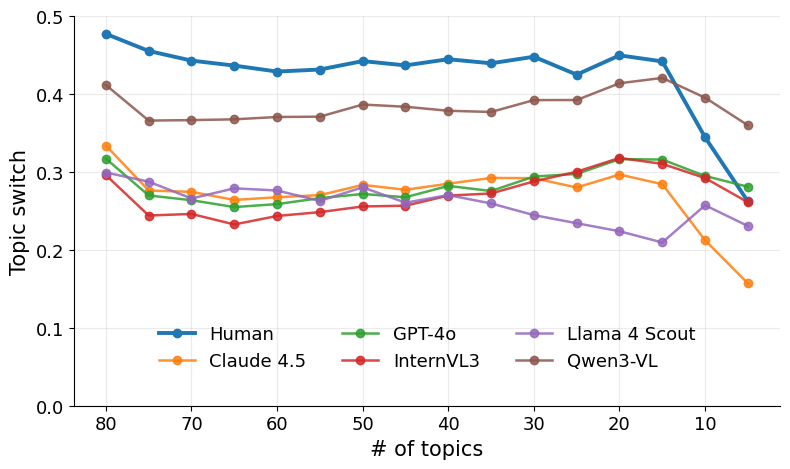

Saved analysis_data/topic_modelling/figures/short_topic_switch_rate_60_highlight_15_to_5.pdf


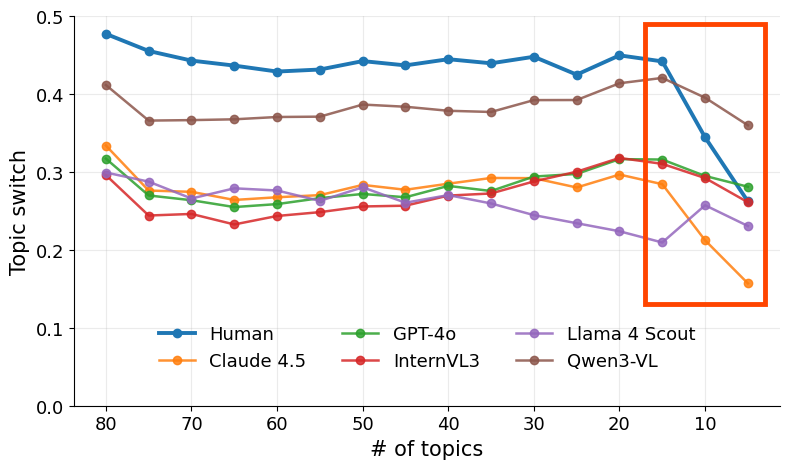

In [16]:
# short prompt, 60 stories
plot_topic_switch_curve(
    profile_summary_60,
    prompt_name='original',
    output_name='short_topic_switch_rate_60.pdf',
    x_label_fontsize=15,
    y_label_fontsize=15,
    x_tick_fontsize=13,
    y_tick_fontsize=13,
    legend_fontsize=13,
    legend_ncol=3,
    legend_anchor=(0.5, 0.05),
)

# long prompt, 54 stories
# plot_topic_switch_curve(
#     profile_summary_54,
#     prompt_name='large',
#     output_name='long_topic_switch_rate_54.pdf',
#     x_label_fontsize=15,
#     y_label_fontsize=15,
#     x_tick_fontsize=13,
#     y_tick_fontsize=13,
#     legend_fontsize=11,
#     legend_ncol=3,
#     legend_anchor=(0.5, 0.03),
# )

# short prompt with highlighted nr_topics window [15, 5]
plot_topic_switch_curve(
    profile_summary_60,
    prompt_name='original',
    output_name='short_topic_switch_rate_60_highlight_15_to_5.pdf',
    x_label_fontsize=15,
    y_label_fontsize=15,
    x_tick_fontsize=13,
    y_tick_fontsize=13,
    legend_fontsize=13,
    legend_ncol=3,
    legend_anchor=(0.5, 0.05),
    highlight_x_range=(17, 3),
    highlight_y_range=(0.13, 0.49),
    highlight_edgecolor='orangered',
    highlight_linewidth=3.5,
    highlight_linestyle='-',
)